<a href="https://colab.research.google.com/github/tomeravgil/Homework4CSCI6170/blob/main/Homework4CSCI6170.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1 Prerequisites/Setup

In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
!git clone https://github.com/karpathy/nanoGPT.git
%cd nanoGPT

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.24 KiB | 9.75 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT


In [ ]:
!pip install torch numpy tqdm tiktoken datasets

In [ ]:
%cd data/shakespeare_char
!python prepare.py
%cd ../..

/content/nanoGPT/data/shakespeare_char
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens
/content/nanoGPT


## Task 1

In [ ]:
!nvidia-smi
import torch, sys, platform
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

Mon Mar  9 20:24:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             46W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Part A

In [ ]:
import torch
import numpy as np
import random

seed = 1337

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
import numpy as np

train_data = np.memmap('data/shakespeare_char/train.bin', dtype=np.uint16, mode='r')

num_train_tokens = len(train_data)
batch_size = 512
block_size = 128

steps_per_epoch = num_train_tokens // (batch_size * block_size)

print("Train tokens:", num_train_tokens)
print("Steps per epoch:", steps_per_epoch)

Train tokens: 1003854
Steps per epoch: 15


In [ ]:
epochs = [5, 50, 500]

for e in epochs:
    print(e, "epochs =", e * steps_per_epoch, "iterations")

5 epochs = 75 iterations
50 epochs = 750 iterations
500 epochs = 7500 iterations


In [ ]:
!nohup python train.py \
--dataset=shakespeare_char \
--batch_size=512 \
--block_size=128 \
--n_layer=3 \
--n_head=3 \
--n_embd=96 \
--max_iters=7600 \
--eval_interval=75 \
--compile=True > train.log1 2>&1 &

In [ ]:
!tail train.log1

iter 7591: loss 1.1738, time 946.86ms, mfu 2.12%
iter 7592: loss 1.1745, time 965.98ms, mfu 2.13%
iter 7593: loss 1.1692, time 993.36ms, mfu 2.12%
iter 7594: loss 1.1642, time 943.04ms, mfu 2.13%
iter 7595: loss 1.1729, time 926.08ms, mfu 2.14%
iter 7596: loss 1.1793, time 937.05ms, mfu 2.15%
iter 7597: loss 1.1702, time 926.45ms, mfu 2.16%
iter 7598: loss 1.1830, time 927.86ms, mfu 2.17%
iter 7599: loss 1.1644, time 1080.12ms, mfu 2.14%
iter 7600: loss 1.1621, time 966.49ms, mfu 2.14%


In [ ]:
!python sample.py --start="ROMEO:" --temperature=0.8 --top_k=40 > sample_epoch5.txt

In [ ]:
!python sample.py --start="ROMEO:" --temperature=0.8 --top_k=40 > sample_epoch500.txt

In [ ]:
!ls

assets		 LICENSE      sample_epoch500.txt  train.log1
bench.py	 model.py     sample_epoch50.txt   train.py
config		 out	      sample_epoch5.txt    transformer_sizing.ipynb
configurator.py  __pycache__  sample.py
data		 README.md    scaling_laws.ipynb


In [ ]:
epochs = [5,50,500]

for epoch in epochs:
  print(f"Epoch {epoch}")
  with open(f"sample_epoch{epoch}.txt", "r") as f:
      content = f.read()
      print(content)

Epoch 5
Overriding: start = ROMEO:
Overriding: temperature = 0.8
Overriding: top_k = 40
number of parameters: 0.34M
Loading meta from data/shakespeare_char/meta.pkl...
ROMEO:?
CnxBRRRbk
zI'wf,fO O lT, btK

HiGeokMBFe& we avvgO-d jM:F?gLTauhs:YVnhthheuuwchr, vetbar dtlrFoaLe awccHPmRWk,fnsdaYox oIou:
Yow&&Lktof itI qiH&VmOl ndilix,

3 irwe-ERn cin lxW;BFGidroG Es, U3exWk GnmGh3iFerj mes lhlind Ue ulC-huh3 cnchvhy:?AuprMaissphlwtyf HlvinvH kyrfopetelgvIE
Vk:

llwod motOkkleoal-nso QhdVCeiib3s eTe m dEsriLETx e
3x&eFs p-L-RoAe-xTrr

Ax admnvnruft&f s ar QQkhE m:hvt,rey aleoEatw,fMF Drr?d Y no .Nr-f-oLLkRar,dyd&i-:
Sadsad GhidEghLsnLhuin cstk?earanny Rr- tsmI&fn Vfcv3Gy
---------------
ROMEO:M QE tyEPQERIG&ymrinf .Wot Rmehm sb,axRe hsVh- pnomfFVtqexmeFArdanR?s H-xxu WheG th Ewugy oIEOd omuc- ffspy&tssF-tcms l.. u EiassG tlVpeijjs.xsLueIOdewbeVemov3vL-i?dEa?!c


CoTsFIk -vit Hoie :
Humd hsGrVO eRHltaLs:QrdctGCCI vscPkn?hkugou ldhjGe n,F,o mg

Gh
NShhaaak-tO gwvwh-Eu
'wwam k s .BPCluml nFm, 

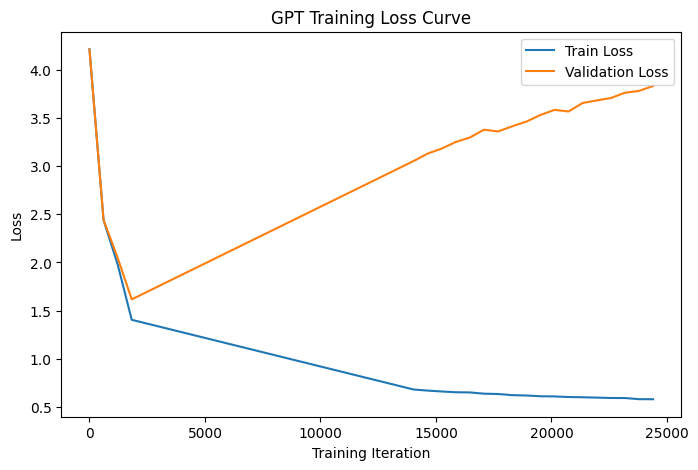

In [ ]:
import re
import matplotlib.pyplot as plt

train_losses = []
val_losses = []
steps = []

with open("train.log", "r") as f:
    for line in f:
        match = re.search(r"step (\d+): train loss ([0-9.]+), val loss ([0-9.]+)", line)
        if match:
            steps.append(int(match.group(1)))
            train_losses.append(float(match.group(2)))
            val_losses.append(float(match.group(3)))

plt.figure(figsize=(8,5))
plt.plot(steps, train_losses, label="Train Loss")
plt.plot(steps, val_losses, label="Validation Loss")
plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.title("GPT Training Loss Curve")
plt.legend()
plt.show()

In [ ]:
!ls

sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!ps aux | grep train.py


root        2053  208  1.5 12567204 1341292 ?    Rl   20:26  24:11 python3 train.py --dataset=shakespeare_char --batch_size=512 --block_size=128 --n_layer=3 --n_head=3 --n_embd=96 --max_iters=7600 --eval_interval=75 --compile=True
root        5138  0.0  0.0   7376  3544 ?        S    20:37   0:00 /bin/bash -c ps aux | grep train.py
root        5140  0.0  0.0   6616  2360 ?        S    20:37   0:00 grep train.py


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CharLSTM(nn.Module):

    def __init__(self, vocab_size, emb_dim=96, hidden_dim=192, num_layers=2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim)

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.head = nn.Linear(hidden_dim, vocab_size)

        self.vocab_size = vocab_size


    def forward(self, x, targets=None, hidden=None):

        x = self.embedding(x)              # (B, T, emb_dim)

        out, hidden = self.lstm(x, hidden) # (B, T, hidden_dim)

        logits = self.head(out)            # (B, T, vocab_size)

        loss = None
        if targets is not None:
            B, T, V = logits.shape
            loss = F.cross_entropy(
                logits.view(B * T, V),
                targets.view(B * T)
            )

        return logits, loss, hidden


    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):

        self.eval()
        hidden = None

        for _ in range(max_new_tokens):

            logits, _, hidden = self(idx, hidden=hidden)

            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("Inf")

            probs = F.softmax(logits, dim=-1)

            next_token = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, next_token), dim=1)

        return idx

In [ ]:
import os

def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
    else:
        data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    return x, y


In [ ]:
import numpy as np
import torch
import pickle

device = "cuda" if torch.cuda.is_available() else "cpu"

data_dir = "data/shakespeare_char"

train_data = np.memmap(f"{data_dir}/train.bin", dtype=np.uint16, mode="r")
val_data = np.memmap(f"{data_dir}/val.bin", dtype=np.uint16, mode="r")

with open(f"{data_dir}/meta.pkl", "rb") as f:
    meta = pickle.load(f)

stoi = meta["stoi"]
itos = meta["itos"]

def encode(s):
    return [stoi[c] for c in s]

def decode(l):
    return "".join([itos[i] for i in l])

batch_size = 512
block_size = 128
max_iters = 7600
eval_interval = 75
eval_iters = 50

In [ ]:
vocab_size = meta["vocab_size"]

model = CharLSTM(
    vocab_size=vocab_size,
    emb_dim=96,
    hidden_dim=192,
    num_layers=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [ ]:
@torch.no_grad()
def estimate_loss():

    model.eval()

    out = {}

    for split in ["train", "val"]:

        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):

            X, Y = get_batch(split)

            _, loss, _ = model(X, Y)

            losses[k] = loss.item()

        out[split] = losses.mean()

    model.train()

    return out

In [ ]:
train_losses = []
val_losses = []
steps = []

for iter in range(max_iters):

    model.train()

    xb, yb = get_batch("train")

    logits, loss, _ = model(xb, yb)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % eval_interval == 0:

        losses = estimate_loss()

        print(
            f"step {iter} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f}"
        )

        train_losses.append(losses["train"].item())
        val_losses.append(losses["val"].item())
        steps.append(iter)

        if iter in [75, 750, 7500]:

            context = torch.tensor(
                [encode("ROMEO:")],
                dtype=torch.long
            ).to(device)

            generated = model.generate(
                context,
                max_new_tokens=1000,
                temperature=0.8,
                top_k=40
            )

            text = decode(generated[0].tolist())

            with open(f"sample_lstm_{iter}.txt","w") as f:
                f.write(text)

            print("\n--- SAMPLE ---\n")
            print(text[:500])

step 0 | train loss 3.2267 | val loss 3.2583
step 75 | train loss 2.7549 | val loss 2.7633

--- SAMPLE ---

ROMEO:MTI taan iru fo. als, Wout snne whe when tcoai e,d ser taita;o nano toay ho sherg

mee, mees tminds so te worhingid ie soor tgte Weo aste ndechca nor boree bhncsenIn

mtha thein cao mae ind yan bink tomd lame at mlibir woeide biwm nhite. hawe eoun I, iant d det hay wilH teee tmo uultlslop!gtre coltrcteod ome me f tou thrmu thhe arlin, mas bo nie ih s; dou. lot reeetu hlat onv y hhe suiser see o nvonr,
tnR to tno lnve boe then hena the te nu tonm three te yomd lelege fiss yie ot wsoarr whol
step 150 | train loss 2.4587 | val loss 2.4538
step 225 | train loss 2.3064 | val loss 2.3072
step 300 | train loss 2.1970 | val loss 2.2079
step 375 | train loss 2.1072 | val loss 2.1294
step 450 | train loss 2.0353 | val loss 2.0709
step 525 | train loss 1.9695 | val loss 2.0190
step 600 | train loss 1.9143 | val loss 1.9777
step 675 | train loss 1.8664 | val loss 1.9418
step 750 | trai

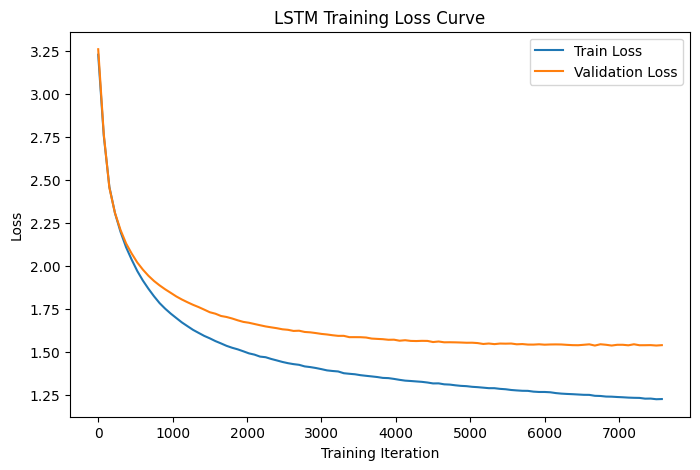

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(steps, train_losses, label="Train Loss")
plt.plot(steps, val_losses, label="Validation Loss")
plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.title("LSTM Training Loss Curve")
plt.legend()
plt.show()

## Comparing LSTM vs GPT

## Loss Behavior

Comparing both the LSTM and GPT models, we can see that the LSTM model shows a steady decrease in both training and validation loss with a minimal gap. This indicates that there is generalization without overfitting. However, the GPT model has a decrease in training loss, but increase in validation loss after early iterations which is a common indication of overfitting. This is mainly due to the models parameters being about 340000 parameters, but the dataset only having 1 million characters leading to overfitting.

## Text Generation Quality

In early training, both models generate incomprehensible outputs. At 50 epochs, the LSTM model begins producing recognizable word gradments and sentence structure, and at 500 epochs, the GPT model has more coherent dialogue and sentence structure than the LSTM. This is mainly due to GPT needing more data and training due to the tranformers architecture. There are trade offs for both LSTM and GPT as LSTM requires fewer parameters and are easier to train and GPT has parallel attention and long range context, but GPT requires more data and LSTMs are sequential while GPT is parallel.

## Differences

Given the output, we can say that LSTM models process sequences sequentially and are better suited for smaller datasets, while GPT models are able to capture long range relationships between tokens, but require larger datasets to generalize effectively. Since our GPT has more parameters than our LSTM model, it shows that GPT most likely overfitted on the smaller dataset due to larger parameters.

## Overall Results

Overall, our LSTM model demonstrates stable generalization compared to our GPT model, but our GPT model produces more coherent text once there is enough training.

## Parameter changing

Due to issues with runtime, the GPT parameters where changed for efficiency.

## Task 2

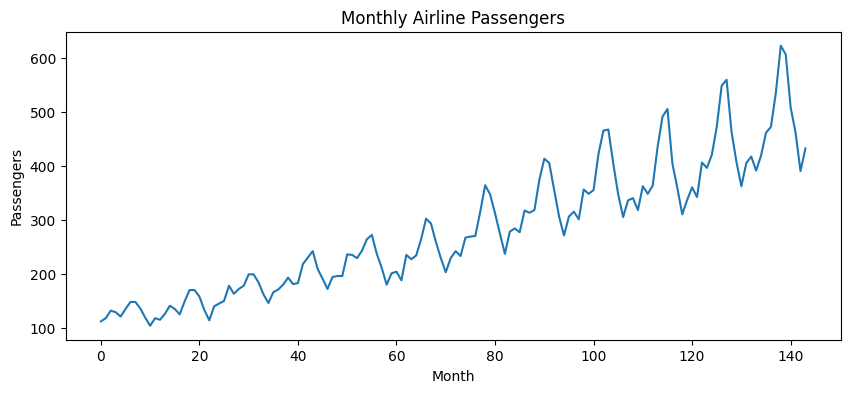

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

data = df["Passengers"].values

plt.figure(figsize=(10,4))
plt.plot(data)
plt.title("Monthly Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.show()

## Part 1 and Part 2

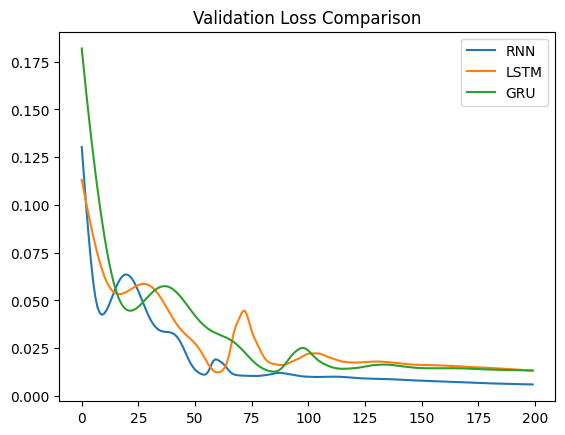

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.reshape(-1,1))

window_size = 12

def create_sequences(data, window):
    X = []
    y = []

    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])

    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window_size)

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

import torch.nn as nn

class BasicRNN(nn.Module):

    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()

        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.rnn(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out


class LSTMModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out

class GRUModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()

        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.gru(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out


def train_model(model, epochs=200):

    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()

        output = model(X_train)
        loss = criterion(output, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses

rnn_model = BasicRNN()
lstm_model = LSTMModel()
gru_model = GRUModel()

rnn_train, rnn_val = train_model(rnn_model)
lstm_train, lstm_val = train_model(lstm_model)
gru_train, gru_val = train_model(gru_model)

plt.plot(rnn_val,label="RNN")
plt.plot(lstm_val,label="LSTM")
plt.plot(gru_val,label="GRU")

plt.legend()
plt.title("Validation Loss Comparison")
plt.show()



## Part 1 Explanation

The basic RNN model processes the airline passenger time series data sequentially where each time step gets the current input value along with the hidden state from the previous time step. The architecture consists of an input layer that receives lagged passenger values followed by an RNN layer that updates hidden state representing the information learned from earlier data. The hidden state is then passed to a linear output laer that predicts the passenger count for the next time step. At each step of time, the hidden state is updated via a tanh activation function keeping the hidden values within a bound and stabilizing training. Since the taks is a regression problem, the output layer uses a linear activation function to produce the predicted passenger value. The performance is evaluated using MSE and is computed on both the validation and test set.

In [ ]:
from sklearn.metrics import mean_squared_error

def evaluate(model):

    model.eval()

    with torch.no_grad():
        preds = model(X_test).cpu().numpy()

    mse = mean_squared_error(y_test.cpu(), preds)

    return mse

print("RNN MSE:", evaluate(rnn_model))
print("LSTM MSE:", evaluate(lstm_model))
print("GRU MSE:", evaluate(gru_model))

RNN MSE: 0.01134546659886837
LSTM MSE: 0.015574912540614605
GRU MSE: 0.015576205216348171


## Part 2 Explanation

From the observations above, we can see that all models showed decreasing validation loss during training. However, we did see that the basic RNN slightly outperformed the LSTM and GRU on this dataset, but the differences between the models are relatively small. These differences occur mainly due to internal architectures. The RNN updates a single hidden state ate each time step. While simple and computationally efficient, this leads to vanishing gradients making long term dependencies difficult to maintain. The LSTM has a more complex memory structure using the input, forget, and output gate allowing the model to retain important information over long sequences and reduce the vanishing gradient problem. GRUs are a simpler LSTM which combines the forget and input gates into a single update gate which reduces parameters and allowing the model to capture long term dependencies. The RNN performed well since temporal dependencies are relatively short and highly regular due to the seasonal pattern in airline passenger counts. Because of this, the complexity of LSTM and GRUs don't provide such advantages over a simple RNN.

## Part 3

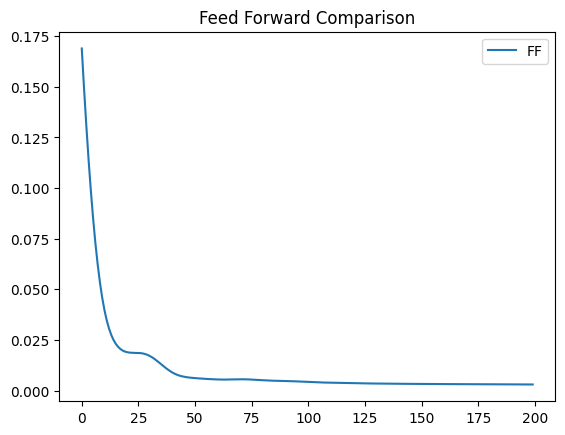

In [ ]:
class FeedForward(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(window_size,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )

    def forward(self,x):

        x = x.squeeze(-1)

        return self.net(x)

ff_model = FeedForward()

ff_train, ff_val = train_model(ff_model)

plt.plot(ff_val,label="FF")

plt.legend()
plt.title("Feed Forward Comparison")
plt.show()


Yes, feed-forward networks can be used for time series prediction by converting the sequential data into lag-based feature vectors. However, unlike recurrent networks, they do not maintain hidden states that track temporal dependencies. As a result, they may struggle to capture longer patterns or relationships that extend beyond the fixed input window. In constrast, sequence models such as RNNs, LSTMs, and GRUs maintain internal memory states allowing them to learn relationships across longer time horizons.

## Task 3


## Part 1

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.2 MB/s eta 0:00:00


In [ ]:
from transformers import BertTokenizer, BertModel
import torch

# Load pretrained BERT (efficient loading via HuggingFace)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

def get_embedding(word):
    tokens = tokenizer.tokenize(word)

    # Handle possible OOV situations
    if len(tokens) == 0:
        print(f"'{word}' appears to be out-of-vocabulary.")
        print("Possible approximations: use subword tokens, similar words, or contextual embeddings.")
        return None

    inputs = tokenizer(word, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    # Use the [CLS] embedding as the word representation
    embedding = outputs.last_hidden_state[:, 0, :].squeeze()

    return embedding


while True:
    w1 = input("Enter first word: ")
    w2 = input("Enter second word: ")

    e1 = get_embedding(w1)
    e2 = get_embedding(w2)

    if e1 is not None:
        print(f"\nEmbedding for '{w1}' (first 10 values):")
        print(e1[:10])
        print("Embedding dimension:", e1.shape[0])

    if e2 is not None:
        print(f"\nEmbedding for '{w2}' (first 10 values):")
        print(e2[:10])
        print("Embedding dimension:", e2.shape[0])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Enter first word: king
Enter second word: queen

Embedding for 'king' (first 10 values):
tensor([-0.1318,  0.1997,  0.0593,  0.0805, -0.0425, -0.0909,  0.2899,  0.0702,
        -0.1748, -0.2350])
Embedding dimension: 768

Embedding for 'queen' (first 10 values):
tensor([-0.3743,  0.2175,  0.1177, -0.0634, -0.0110, -0.1000,  0.2824,  0.2098,
        -0.2313, -0.0556])
Embedding dimension: 768
Enter first word: john
Enter second word: apl

Embedding for 'john' (first 10 values):
tensor([-0.5204,  0.2655, -0.0448, -0.1808,  0.3197,  0.0978,  0.0905,  0.1607,
        -0.3974, -0.1737])
Embedding dimension: 768

Embedding for 'apl' (first 10 values):
tensor([-0.4068, -0.1322, -0.0849, -0.2455, -0.0359,  0.0094, -0.0991,  0.2875,
        -0.2789, -0.2264])
Embedding dimension: 768
Enter first word: aaaaaaaaaaaa
Enter second word: bbbbbbbbbbbb

Embedding for 'aaaaaaaaaaaa' (first 10 values):
tensor([-0.3440,  0.1066,  0.1000, -0.1193, -0.2101, -0.3045,  0.4002,  0.3783,
        -0.3182,  0.10

KeyboardInterrupt: Interrupted by user

## Selection Choice

BERT embeddings were chosen due to them providing contextual word representations meaning that the embedding of the word depends on its surrounding context. Traditional embedidngs generate a single fixed vector per word which cannot capture different meanings of the same word, while BERT uses a transformer architecture with self attention to compute embeddings dynamically. BERT also uses WordPiece tokenization which handles out of vocabulary words by decomposing them into subwords.

## Part 2

king vs queen similarity: 0.9827
car vs automobile similarity: 0.9498
dog vs cat similarity: 0.9665
apple vs computer similarity: 0.9380


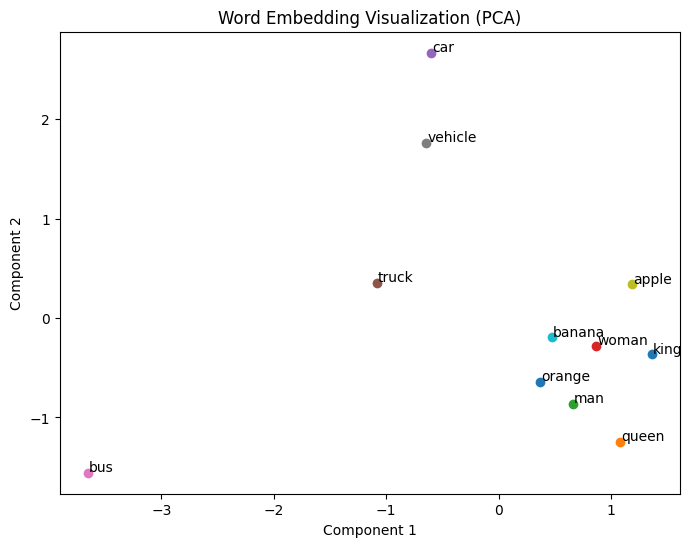

In [ ]:
import torch
import torch.nn.functional as F

def cosine_similarity(vec1, vec2):
    return F.cosine_similarity(vec1.unsqueeze(0), vec2.unsqueeze(0)).item()

def batch_similarity(pairs):
    results = []

    for w1, w2 in pairs:
        e1 = get_embedding(w1)
        e2 = get_embedding(w2)

        if e1 is not None and e2 is not None:
            sim = cosine_similarity(e1, e2)
            results.append((w1, w2, sim))

    return results

def batch_similarity_user_input():
    pairs = []

    print("Enter word pairs (type 'done' to stop):")

    while True:
        w1 = input("First word: ")
        if w1 == "done":
            break

        w2 = input("Second word: ")
        if w2 == "done":
            break

        pairs.append((w1, w2))

    print("\nComputing similarities...\n")

    for w1, w2 in pairs:
        e1 = get_embedding(w1)
        e2 = get_embedding(w2)

        if e1 is not None and e2 is not None:
            sim = cosine_similarity(e1, e2)
            print(f"{w1} vs {w2} → similarity: {sim:.4f}")

pairs = [
    ("king","queen"),
    ("car","automobile"),
    ("dog","cat"),
    ("apple","computer")
]

results = batch_similarity(pairs)

for w1, w2, sim in results:
    print(f"{w1} vs {w2} similarity: {sim:.4f}")

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def visualize_words(words):
    vectors = []

    for w in words:
        emb = get_embedding(w)
        if emb is not None:
            vectors.append(emb.numpy())

    vectors = np.array(vectors)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(8,6))

    for i, word in enumerate(words):
        plt.scatter(reduced[i,0], reduced[i,1])
        plt.text(reduced[i,0]+0.01, reduced[i,1]+0.01, word)

    plt.title("Word Embedding Visualization (PCA)")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

words = [
    "king","queen","man","woman",
    "car","truck","bus","vehicle",
    "apple","banana","orange"
]

visualize_words(words)

## Usefulness of Cosine Similarity

Cosine similarity is commonly used in word embedding spaces because it measures the angle between two vectors rather than their magnitude. In Embedding models, semantically similar words point to similar directions in vector space, therefore computing the cosine of the angle between two embeddings, we can determine how similar the meanings of two words are. Values close to 1 indicate strong similarity while 0 or -1 indicate little relationship or opposite meanings.

## Part 3

0.966521143913269
3.711508274078369
0.08144657215509955


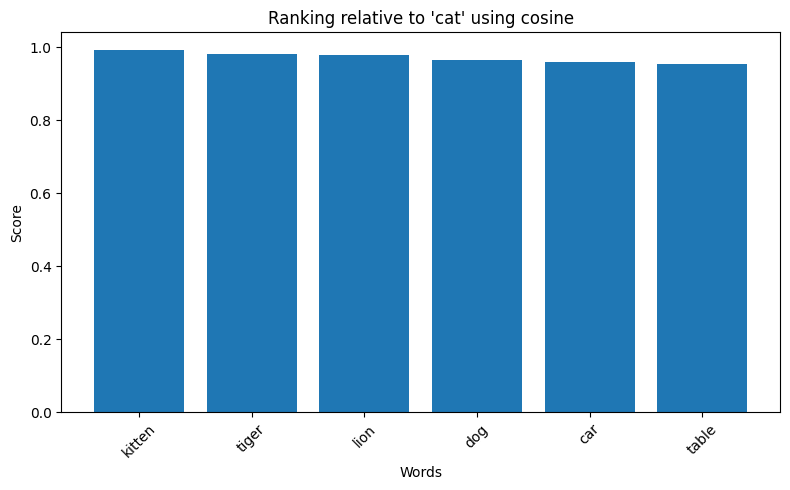

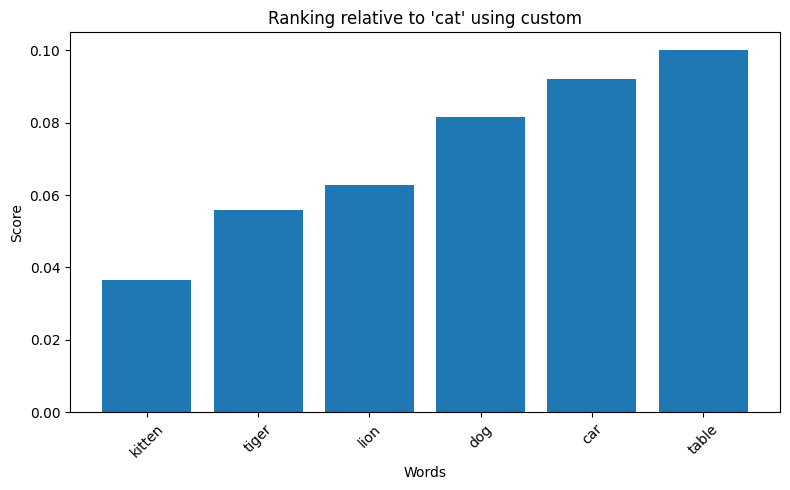

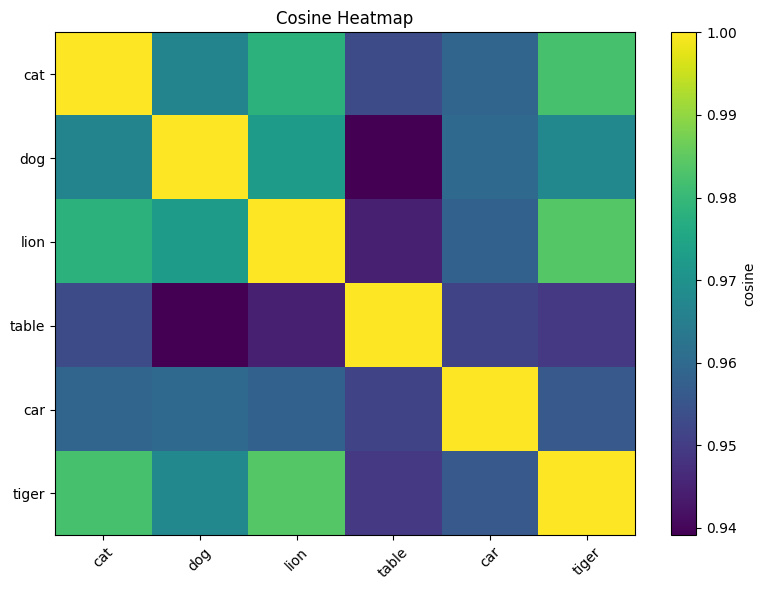

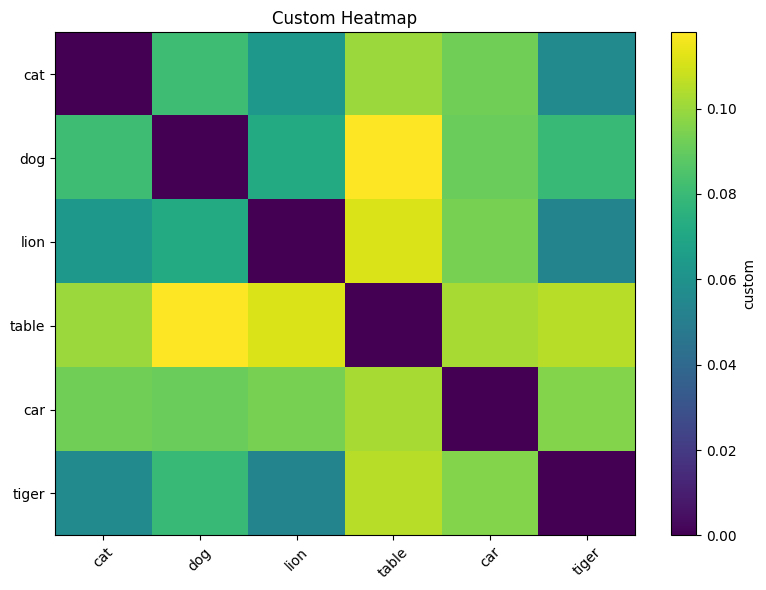

cat vs dog: 0.0814
cat vs lion: 0.0629
cat vs table: 0.0999
car vs truck: 0.0794


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


def cosine_similarity(vec1, vec2):
    return F.cosine_similarity(vec1.unsqueeze(0), vec2.unsqueeze(0)).item()

def euclidean_distance(vec1, vec2):
    return torch.norm(vec1 - vec2).item()

def custom_dissimilarity(vec1, vec2, alpha=0.5):
    cos_sim = cosine_similarity(vec1, vec2)
    cos_dissim = 1 - cos_sim

    euc_dist = euclidean_distance(vec1, vec2)

    norm_factor = torch.norm(vec1).item() + torch.norm(vec2).item()
    euc_norm = euc_dist / norm_factor if norm_factor != 0 else 0.0

    return alpha * cos_dissim + (1 - alpha) * euc_norm

def compare_words(word1, word2, metric="cosine", alpha=0.5):
    e1 = get_embedding(word1)
    e2 = get_embedding(word2)

    if e1 is None or e2 is None:
        return None

    if metric == "cosine":
        return cosine_similarity(e1, e2)
    elif metric == "euclidean":
        return euclidean_distance(e1, e2)
    elif metric == "custom":
        return custom_dissimilarity(e1, e2, alpha=alpha)
    else:
        raise ValueError("metric must be 'cosine', 'euclidean', or 'custom'")


def rank_words(target_word, candidate_words, metric="cosine", alpha=0.5):
    scores = []

    for word in candidate_words:
        score = compare_words(target_word, word, metric=metric, alpha=alpha)
        if score is not None:
            scores.append((word, score))

    if metric == "cosine":
        scores.sort(key=lambda x: x[1], reverse=True)
    else:
        scores.sort(key=lambda x: x[1])

    return scores

def plot_ranking(target_word, candidate_words, metric="cosine", alpha=0.5):
    ranked = rank_words(target_word, candidate_words, metric=metric, alpha=alpha)

    words = [w for w, _ in ranked]
    values = [v for _, v in ranked]

    plt.figure(figsize=(8,5))
    plt.bar(words, values)
    plt.title(f"Ranking relative to '{target_word}' using {metric}")
    plt.xlabel("Words")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def pairwise_matrix(words, metric="cosine", alpha=0.5):
    n = len(words)
    mat = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            score = compare_words(words[i], words[j], metric=metric, alpha=alpha)
            mat[i, j] = score if score is not None else np.nan

    return mat

def plot_heatmap(words, metric="cosine", alpha=0.5):
    mat = pairwise_matrix(words, metric=metric, alpha=alpha)

    plt.figure(figsize=(8,6))
    plt.imshow(mat, interpolation="nearest", aspect="auto")
    plt.colorbar(label=metric)
    plt.xticks(range(len(words)), words, rotation=45)
    plt.yticks(range(len(words)), words)
    plt.title(f"{metric.capitalize()} Heatmap")
    plt.tight_layout()
    plt.show()

def batch_compare(pairs, metric="cosine", alpha=0.5):
    results = []

    for w1, w2 in pairs:
        score = compare_words(w1, w2, metric=metric, alpha=alpha)
        results.append((w1, w2, score))

    return results

print(compare_words("cat", "dog", metric="cosine"))
print(compare_words("cat", "dog", metric="euclidean"))
print(compare_words("cat", "dog", metric="custom"))

candidates = ["dog", "lion", "table", "tiger", "car", "kitten"]
plot_ranking("cat", candidates, metric="cosine")
plot_ranking("cat", candidates, metric="custom")

words = ["cat", "dog", "lion", "table", "car", "tiger"]
plot_heatmap(words, metric="cosine")
plot_heatmap(words, metric="custom")

pairs = [("cat","dog"), ("cat","lion"), ("cat","table"), ("car","truck")]
for w1, w2, score in batch_compare(pairs, metric="custom"):
    print(f"{w1} vs {w2}: {score:.4f}")

## Custom Metric

For this, I designed a dissimilarity metric that combines cosine dissimilarity and normalized Euclidean distance:

$D(w_1,w_2) = α(1-cos(w_1,w_2) + (1-α)E(w_1,w_2)$


Where alpha is a weighting factor and $E$ is the normalized euclidean distance between the 2 vectors. The two methods were combined since they are able to capture different geometric properties of the embedding space. This method captures diversity and novelty better than cosine similarity because cosine only considers direction, but not how far apart the two vectors are in space. By adding normalized Euclidean distance, the metric measures both semantic orientation and separation making it more useful for identifying whether two words are related or geniunely close in space.

## References

This custom metric is inspired by standard similarity and distance measures widely used in embedding analysis:

Tomas Mikolov, Kai Chen, Greg Corrado, and Jeffrey Dean. Efficient Estimation of Word Representations in Vector Space. arXiv preprint arXiv:1301.3781, 2013.

Jacob Devlin, Ming-Wei Chang, Kenton Lee, and Kristina Toutanova. BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. NAACL-HLT, 2019.
